# Case Study 1 — SOLUTION: Credit Approval (PD Model)

Reference solution for `case1_credit_approval.ipynb`. Uses `data/case1_credit_approval.csv.gz`
(application + bureau features, target `TARGET`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "data"
df = pd.read_csv(f"{DATA_DIR}/case1_credit_approval.csv.gz")
print(df.shape)
df.head()


(307511, 35)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,BUREAU_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_AMT_CREDIT_SUM_TOTAL,BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL,BUREAU_AMT_CREDIT_SUM_OVERDUE_TOTAL,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.083037,0.262949,0.139376,8.0,2.0,865055.565,245781.0,0.0,0.0,-874.00
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.311267,0.622246,NaN,4.0,1.0,1017400.500,0.0,0.0,0.0,-1400.75
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,0.555912,0.729567,2.0,0.0,189037.800,0.0,0.0,0.0,-867.00
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,0.322738,NaN,1.0,0.0,146250.000,0.0,0.0,0.0,-1149.00


## Task 1 — Load & Explore

In [2]:
target_rate = df["TARGET"].mean()
print(f"Default rate: {target_rate:.3%}")
print(df["TARGET"].value_counts())


Default rate: 8.073%
TARGET
0    282686
1     24825
Name: count, dtype: int64


With ~8% positive class, **accuracy** is misleading: a model predicting "no default"
for everyone scores ~92% accuracy while being useless. **PR-AUC** focuses on the
minority (positive) class and is far more informative for imbalanced credit risk problems.

In [3]:
ext_bureau_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] + \
    [c for c in df.columns if c.startswith("BUREAU_")]
df[ext_bureau_cols].isna().mean().sort_values(ascending=False)


EXT_SOURCE_1                           0.563811
EXT_SOURCE_3                           0.198253
BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL       0.143149
BUREAU_COUNT                           0.143149
BUREAU_ACTIVE_COUNT                    0.143149
BUREAU_AMT_CREDIT_SUM_TOTAL            0.143149
BUREAU_CREDIT_DAY_OVERDUE_MAX          0.143149
BUREAU_AMT_CREDIT_SUM_OVERDUE_TOTAL    0.143149
BUREAU_DAYS_CREDIT_MEAN                0.143149
EXT_SOURCE_2                           0.002146
dtype: float64

`EXT_SOURCE_1` is missing for ~56% of applicants (a normalized external scoring source
not available for everyone). `BUREAU_*` columns are missing for ~1.7M / 307k applicants who
have **no record in the credit bureau** — i.e. no previously tracked external credit. This
is informative (likely "thin file" / new-to-credit customers) rather than random, so it
should be imputed with a sentinel value or flagged, not dropped.

## Task 2 — Feature Engineering

In [4]:
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["CREDIT_GOODS_RATIO"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]

df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

# DAYS_EMPLOYED has a well-known anomalous placeholder of 365243 (used for
# pensioners / unemployed) -> treat as missing rather than ~1000 years employed
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["YEARS_EMPLOYED"] = -df["DAYS_EMPLOYED"] / 365.25

df["EXTERNAL_DEBT_INCOME_RATIO"] = df["BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL"] / df["AMT_INCOME_TOTAL"]

new_feats = ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_GOODS_RATIO",
              "AGE_YEARS", "YEARS_EMPLOYED", "EXTERNAL_DEBT_INCOME_RATIO"]
df[new_feats].describe()


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,AGE_YEARS,YEARS_EMPLOYED,EXTERNAL_DEBT_INCOME_RATIO
count,307511.000000,307499.000000,307233.000000,307511.000000,252137.000000,263491.000000
mean,3.957570,0.180930,1.122995,43.906900,6.527500,3.595340
std,2.689728,0.094574,0.124045,11.947950,6.402081,8.046950
min,0.004808,0.000224,0.150000,20.503765,-0.000000,-15.514574
25%,2.018667,0.114782,1.000000,33.984942,2.099932,0.000000
50%,3.265067,0.162833,1.118800,43.121150,4.511978,1.175437
75%,5.159880,0.229067,1.198000,53.886379,8.692676,4.275311
max,84.736842,1.875965,6.000000,69.073238,49.040383,1651.843611


**Rationale:**
- `CREDIT_INCOME_RATIO` / `ANNUITY_INCOME_RATIO`: higher leverage relative to income -> higher
  default risk.
- `CREDIT_GOODS_RATIO`: credit amount above the goods price suggests financing fees/add-ons,
  potentially riskier loans.
- `AGE_YEARS`: younger applicants tend to have less stable credit history.
- `YEARS_EMPLOYED`: longer tenure -> more stable income -> lower risk. The 365243 anomaly is
  set to NaN so it doesn't get read as ~1000 years.
- `EXTERNAL_DEBT_INCOME_RATIO`: how leveraged the applicant already is *outside* this bank,
  relative to income.

## Task 3 — Preprocessing & Split

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

feature_cols = [c for c in df.columns if c not in ("SK_ID_CURR", "TARGET")]
X = df[feature_cols]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical features")

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

X_train_proc = preprocess.fit_transform(X_train)
X_val_proc = preprocess.transform(X_val)
print(X_train_proc.shape, X_val_proc.shape)


/tmp/ipykernel_26103/1165683717.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


29 numeric, 10 categorical features


(246008, 139) (61503, 139)


If the imputer/encoder were fit on the **full** dataset before splitting, statistics
like the median or most-frequent category would leak information from the validation set
into training — a (mild but real) form of data leakage that makes validation performance
overly optimistic.

## Task 4 — Model Training & Evaluation

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb

# Baseline: Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_proc, y_train)
proba_lr = logreg.predict_proba(X_val_proc)[:, 1]

print("Logistic Regression")
print(f"  ROC-AUC: {roc_auc_score(y_val, proba_lr):.4f}")
print(f"  PR-AUC : {average_precision_score(y_val, proba_lr):.4f}")


Logistic Regression
  ROC-AUC: 0.6208
  PR-AUC : 0.1195


/home/muzzi/first_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
# Gradient boosting with native categorical handling
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_val_lgb[c] = pd.Categorical(X_val_lgb[c], categories=X_train_lgb[c].cat.categories)

lgbm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight="balanced", random_state=42, verbose=-1,
)
lgbm.fit(X_train_lgb, y_train, categorical_feature=cat_cols)
proba_lgb = lgbm.predict_proba(X_val_lgb)[:, 1]

print("LightGBM")
print(f"  ROC-AUC: {roc_auc_score(y_val, proba_lgb):.4f}")
print(f"  PR-AUC : {average_precision_score(y_val, proba_lgb):.4f}")


LightGBM
  ROC-AUC: 0.7627
  PR-AUC : 0.2553


## Task 5 — Explainability (SHAP)

/home/muzzi/first_project/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


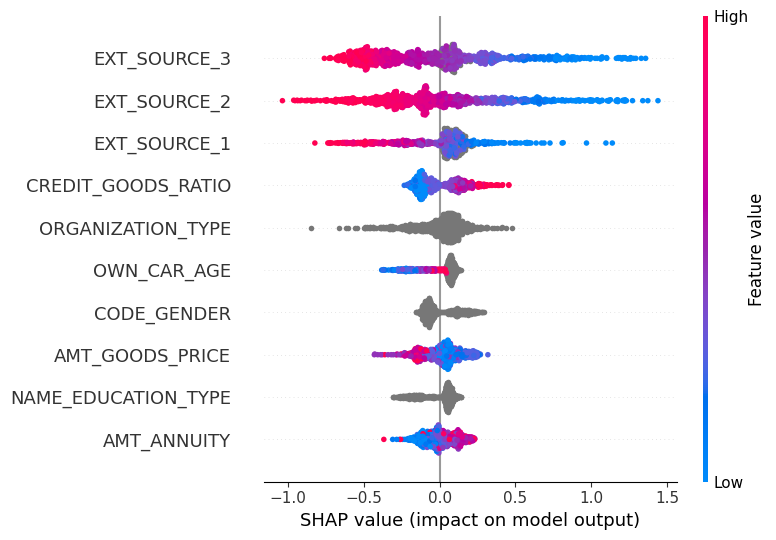

In [8]:
import shap

explainer = shap.TreeExplainer(lgbm)
sample = X_val_lgb.sample(1000, random_state=42)
shap_values = explainer.shap_values(sample)

# shap_values may be a list (one array per class) or a single array for binary LGBM
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, sample, show=False, max_display=10)
plt.tight_layout()
plt.show()


/home/muzzi/first_project/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Predicted default probability: 0.975


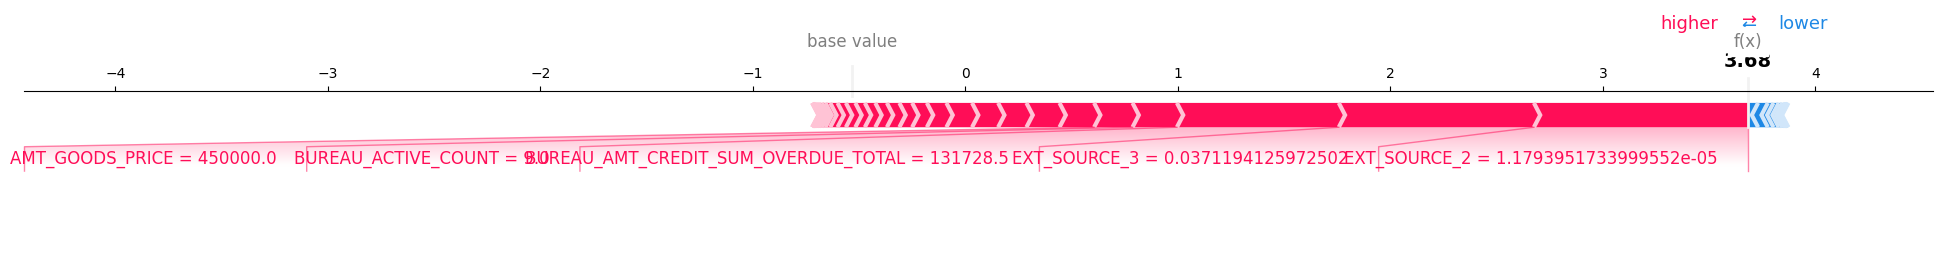

In [9]:
# Individual explanation for one high-risk applicant
high_risk_idx = np.argsort(-proba_lgb)[0]
applicant = X_val_lgb.iloc[[high_risk_idx]]
applicant_sv = explainer.shap_values(applicant)
applicant_sv = applicant_sv[1] if isinstance(applicant_sv, list) else applicant_sv

print(f"Predicted default probability: {proba_lgb[high_risk_idx]:.3f}")
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
    applicant_sv[0], applicant, matplotlib=True, show=False,
)
plt.tight_layout()
plt.show()


**Top drivers** typically include `EXT_SOURCE_1/2/3` (external credit bureau scores),
`AGE_YEARS`, `CREDIT_INCOME_RATIO`/`ANNUITY_INCOME_RATIO`, and `EXTERNAL_DEBT_INCOME_RATIO`
— all consistent with credit risk intuition (lower external scores, younger age, higher
leverage -> higher predicted risk).

For a declined applicant, you'd point to the SHAP values pushing their score up most —
e.g. "a low external credit bureau score and a high loan-to-income ratio were the largest
factors in this decision."

## Task 6 — Risk Segmentation & Policy

In [10]:
results = pd.DataFrame({"y_true": y_val.values, "proba": proba_lgb})
results["risk_band"] = pd.qcut(
    results["proba"], [0, .5, .8, .95, 1],
    labels=["Low", "Medium", "High", "Very High"],
)

band_stats = results.groupby("risk_band").agg(
    n_applicants=("y_true", "size"),
    default_rate=("y_true", "mean"),
).round(4)
band_stats["pct_of_applicants"] = (band_stats["n_applicants"] / len(results)).round(3)
band_stats


,n_applicants,default_rate,pct_of_applicants
risk_band,,,
Low,30752,0.0281,0.50
Medium,18450,0.0784,0.30
High,9225,0.1698,0.15
Very High,3076,0.3537,0.05


**Policy proposal:**
- `Low` / `Medium` (bottom ~80%) -> **auto-approve**. Their observed default rate is well
  below the portfolio average.
- `High` (next ~15%) -> **manual review**. Default rate is meaningfully elevated; a human
  underwriter can weigh compensating factors (e.g. strong `EXT_SOURCE` despite high leverage).
- `Very High` (top ~5%) -> **decline** or require additional collateral/co-signer. This
  band concentrates a large share of total defaults in a small share of applicants.

**Trade-off of lowering the decline threshold:** declining more applicants (e.g. top 10%
instead of top 5%) further reduces the portfolio default rate, but rejects a growing
number of applicants who would have repaid — i.e. lost revenue and potential fair-lending/
business-volume concerns. The right cutoff depends on the bank's cost of a default vs. the
margin on a performing loan.